# Stage 5.1: NSDE 期权定价（无情绪因子版本）

**对照实验**：去除情绪因子 z，验证其在动力学建模中的作用。

**标的资产价格过程**：
```
dS_t = μ_S(S_t, v_t, r, t) dt + σ_S(S_t, v_t, r, t) dW_t^S
```

**波动率过程**：
```
dv_t = μ_v(S_t, v_t, r, t) dt + σ_v(S_t, v_t, r, t) dW_t^v
```

**核心问题**：没有情绪因子的NSDE能否依然超越Heston基准？

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from OptionPricingModel import (
    OptionPricingModel,
    extract_expiry_yymm,
    compute_metrics,
    set_seed,
    SEED,
)
from NeuralSDEPricerNoSentiment import NeuralSDEPricerNoSentiment

set_seed()
plt.rcParams['font.family'] = ["Arial Unicode MS"]

## 1. 数据加载与清洗

In [2]:
# 加载数据，划分训练集(2401-2411)与测试集(2412)
df = pd.read_csv("full_option_trading_data.csv")
df["expiry_yymm"] = df["order_book_id"].apply(extract_expiry_yymm)
train_yymm = [f"24{i:02d}" for i in range(1, 12)]
df_train = df[df["expiry_yymm"].isin(train_yymm)].copy()
df_test = df[df["expiry_yymm"] == "2412"].copy()

def clean_option_data(d):
    d = d.dropna(subset=["underlying_close", "strike_price", "time_to_expire", 
                          "risk_free_rate", "close", "hv_20d", "call_put", "iv"])
    d = d[d["time_to_expire"] > 5/365]
    d = d[d["close"] >= 0.2]
    d = d[d["hv_20d"] > 1e-6]
    d = d[d["iv"] > 1e-8]
    return d

df_train = clean_option_data(df_train)
df_test = clean_option_data(df_test)
print(f"训练集: {len(df_train)}, 测试集: {len(df_test)}")

训练集: 42349, 测试集: 8701


## 2. 训练 NSDE 模型（无情绪因子）

使用与 stage_5 相同的两组配置：

### 配置1：baseline_mse_hv（原始基线）
- 损失函数：MSE
- v0来源：hv_20d
- 网络结构：[32, 32]
- 蒙特卡洛路径数：2000
- 时间步数：30
- residual_scale：0.3
- 训练轮数：20
- batch_size：64
- 学习率：5e-3
- 训练样本数：500
- 测试样本数：2000
- rho：-0.082（校准值）

### 配置2：baseline_mse_hv_0.2rs_-0.07rho（优化配置）
- 损失函数：MSE
- v0来源：hv_20d
- 网络结构：[32, 32]
- 蒙特卡洛路径数：2000
- 时间步数：30
- residual_scale：0.2（降低）
- 训练轮数：20
- batch_size：64
- 学习率：5e-3
- 训练样本数：2000（增大）
- 测试样本数：2000
- rho：-0.07（调整）

In [3]:
print("=" * 60)
print("配置1：baseline_mse_hv（原始基线）")
print("=" * 60)

# 训练配置1
nsde1 = NeuralSDEPricerNoSentiment(
    hidden_dims=[32, 32],
    n_paths=2000,
    n_steps=30,
    rho=-0.082,
    rho_source='fixed',
    residual_scale=0.3,
    loss_type='mse',
    v0_source='hv_20d',
    random_state=SEED
)

# 训练（使用500个样本）
df_train_sample1 = df_train.sample(n=min(500, len(df_train)), random_state=SEED)
nsde1.fit(
    df_train_sample1,
    epochs=20,
    batch_size=64,
    lr=5e-3,
    n_paths_train=2000,
    verbose=True
)

# 保存模型和历史
with open('nsde_no_sentiment_config1.pkl', 'wb') as f:
    pickle.dump({
        'net_mu_S': nsde1.net_mu_S,
        'net_sigma_S': nsde1.net_sigma_S,
        'net_mu_v': nsde1.net_mu_v,
        'net_sigma_v': nsde1.net_sigma_v,
        'heston_params': nsde1.heston_params,
        'history': nsde1.history_
    }, f)
print("\n已保存配置1模型到 nsde_no_sentiment_config1.pkl")

配置1：baseline_mse_hv（原始基线）
未提供 Heston 基准参数，开始校准...
校准完成: κ=2.944, θ=0.039, σ=1.000, ρ=-0.082, v0=0.018
训练样本数: 500


Epoch 1/20: 100%|██████████| 8/8 [00:30<00:00,  3.78s/it, loss=845.9362, mae=19.1381, grad=4.30e+02] 


  Epoch 1/20, Loss: 1269.313751, MAE: 24.2563
  Grad: μ_S=0.00e+00, σ_S=1.41e+04, μ_v=4.69e+03, σ_v=1.24e+03


Epoch 2/20: 100%|██████████| 8/8 [00:30<00:00,  3.87s/it, loss=722.3396, mae=19.0839, grad=2.06e+02] 


  Epoch 2/20, Loss: 953.926186, MAE: 21.4242
  Grad: μ_S=0.00e+00, σ_S=8.24e+03, μ_v=2.43e+03, σ_v=5.55e+02


...

  Epoch 18/20, Loss: 729.533201, MAE: 17.9485
  Grad: μ_S=0.00e+00, σ_S=5.33e+03, μ_v=1.33e+03, σ_v=2.05e+01


Epoch 19/20: 100%|██████████| 8/8 [00:30<00:00,  3.82s/it, loss=556.9932, mae=13.9404, grad=2.37e+01] 


  Epoch 19/20, Loss: 704.428309, MAE: 17.1700
  Grad: μ_S=0.00e+00, σ_S=4.81e+03, μ_v=1.17e+03, σ_v=1.92e+01


Epoch 20/20: 100%|██████████| 8/8 [00:30<00:00,  3.80s/it, loss=594.3776, mae=15.5380, grad=2.17e+00]

  Epoch 20/20, Loss: 635.645149, MAE: 16.3040
  Grad: μ_S=0.00e+00, σ_S=2.45e+03, μ_v=6.52e+02, σ_v=9.41e+00

已保存配置1模型到 nsde_no_sentiment_config1.pkl


In [4]:
print("\n" + "=" * 60)
print("配置2：baseline_mse_hv_0.2rs_-0.07rho（优化配置）")
print("=" * 60)

# 训练配置2
nsde2 = NeuralSDEPricerNoSentiment(
    hidden_dims=[32, 32],
    n_paths=2000,
    n_steps=30,
    rho=-0.07,
    rho_source='fixed',
    residual_scale=0.2,
    loss_type='mse',
    v0_source='hv_20d',
    random_state=SEED
)

# 训练（使用2000个样本）
df_train_sample2 = df_train.sample(n=min(2000, len(df_train)), random_state=SEED)
nsde2.fit(
    df_train_sample2,
    epochs=20,
    batch_size=64,
    lr=5e-3,
    n_paths_train=2000,
    verbose=True
)

# 保存模型和历史
with open('nsde_no_sentiment_config2.pkl', 'wb') as f:
    pickle.dump({
        'net_mu_S': nsde2.net_mu_S,
        'net_sigma_S': nsde2.net_sigma_S,
        'net_mu_v': nsde2.net_mu_v,
        'net_sigma_v': nsde2.net_sigma_v,
        'heston_params': nsde2.heston_params,
        'history': nsde2.history_
    }, f)
print("\n已保存配置2模型到 nsde_no_sentiment_config2.pkl")


配置2：baseline_mse_hv_0.2rs_-0.07rho（优化配置）
未提供 Heston 基准参数，开始校准...
校准完成: κ=3.387, θ=0.037, σ=1.000, ρ=-0.074, v0=0.019
训练样本数: 2000


Epoch 1/20: 100%|██████████| 32/32 [02:00<00:00,  3.77s/it, loss=842.9991, mae=19.1491, grad=1.50e+02] 


  Epoch 1/20, Loss: 1005.568923, MAE: 20.0660
  Grad: μ_S=0.00e+00, σ_S=4.70e+03, μ_v=1.32e+03, σ_v=3.26e+02


Epoch 2/20: 100%|██████████| 32/32 [02:00<00:00,  3.77s/it, loss=548.5248, mae=15.7921, grad=1.36e+02] 


  Epoch 2/20, Loss: 841.760005, MAE: 17.7871
  Grad: μ_S=0.00e+00, σ_S=2.16e+03, μ_v=5.50e+02, σ_v=1.40e+02


...

  Epoch 18/20, Loss: 817.530111, MAE: 17.7537
  Grad: μ_S=0.00e+00, σ_S=2.43e+03, μ_v=4.35e+02, σ_v=9.52e+01


Epoch 19/20: 100%|██████████| 32/32 [02:00<00:00,  3.77s/it, loss=2032.4137, mae=28.1200, grad=8.74e+00]


  Epoch 19/20, Loss: 791.154873, MAE: 17.3684
  Grad: μ_S=0.00e+00, σ_S=1.67e+03, μ_v=2.76e+02, σ_v=6.28e+01


Epoch 20/20: 100%|██████████| 32/32 [02:00<00:00,  3.77s/it, loss=413.8117, mae=15.0475, grad=1.53e+02] 

  Epoch 20/20, Loss: 791.682267, MAE: 17.3155
  Grad: μ_S=0.00e+00, σ_S=1.53e+03, μ_v=2.67e+02, σ_v=5.49e+01

已保存配置2模型到 nsde_no_sentiment_config2.pkl


## 3. 训练过程可视化

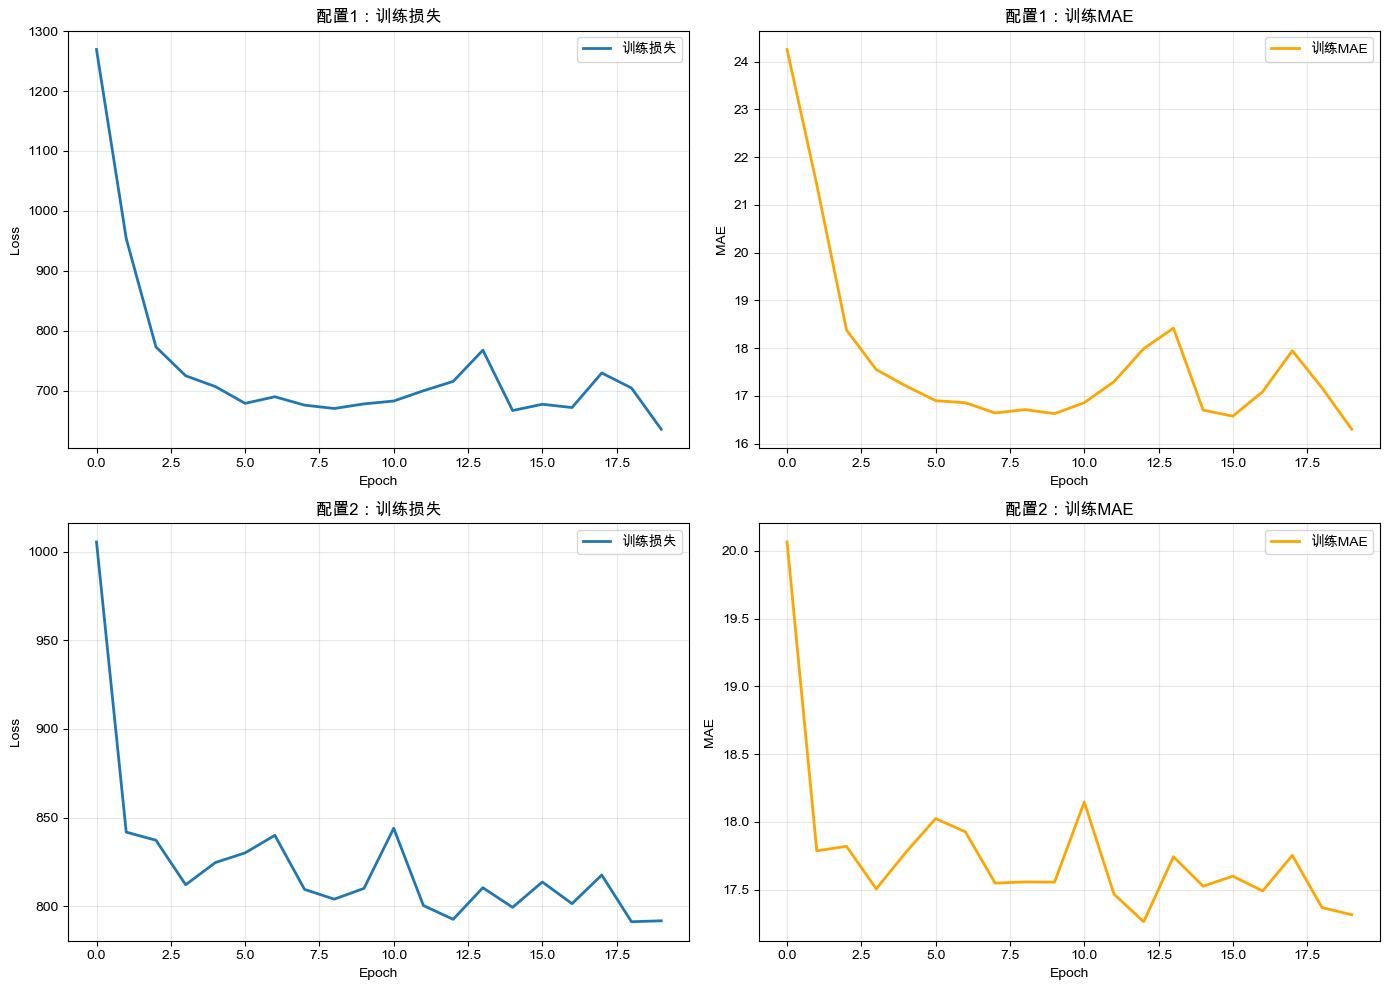


训练历史图已保存到 nsde_no_sentiment_training_history.png


In [5]:
# 绘制训练历史
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 配置1：损失曲线
axes[0, 0].plot(nsde1.history_['loss'], label='训练损失', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('配置1：训练损失')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 配置1：MAE曲线
axes[0, 1].plot(nsde1.history_['mae'], label='训练MAE', color='orange', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].set_title('配置1：训练MAE')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 配置2：损失曲线
axes[1, 0].plot(nsde2.history_['loss'], label='训练损失', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title('配置2：训练损失')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 配置2：MAE曲线
axes[1, 1].plot(nsde2.history_['mae'], label='训练MAE', color='orange', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('MAE')
axes[1, 1].set_title('配置2：训练MAE')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('nsde_no_sentiment_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n训练历史图已保存到 nsde_no_sentiment_training_history.png")

## 4. 测试集评估

与 Heston 基准对比

In [7]:
print("=" * 60)
print("配置1测试集评估")
print("=" * 60)

# 测试集采样
df_test_sample = df_test.sample(n=min(2000, len(df_test)), random_state=SEED)

# NSDE预测（配置1）
print("\nNSDE预测中...")
pred_nsde1, std_err1 = nsde1.predict_batch(
    df_test_sample,
    n_paths_test=5000,
    verbose=True
)

# Heston预测（配置1的基准参数）
print("\nHeston预测中...")
heston_model1 = OptionPricingModel()
heston_model1.set_heston_params(nsde1.heston_params)
pred_heston1 = heston_model1.price_heston_batch(
    df_test_sample
)

# 计算指标
metrics_nsde1 = compute_metrics(df_test_sample['close'].values, pred_nsde1)
heston_metrics_1 = compute_metrics(df_test_sample['close'].values, pred_heston1)

print("\n配置1测试集结果:")
print(f"  NSDE (无情绪因子) - MAE: {metrics_nsde1['MAE']:.4f}, RMSE: {metrics_nsde1['RMSE']:.4f}, MAPE: {metrics_nsde1['MAPE']:.2f}%")
print(f"  Heston 基准       - MAE: {heston_metrics_1['MAE']:.4f}, RMSE: {heston_metrics_1['RMSE']:.4f}, MAPE: {heston_metrics_1['MAPE']:.2f}%")
print(f"\n  MAE 改善: {(1 - metrics_nsde1['MAE'] / heston_metrics_1['MAE']) * 100:.2f}%")

配置1测试集评估

NSDE预测中...


预测中: 100%|██████████| 2000/2000 [03:55<00:00,  8.50it/s]



Heston预测中...

配置1测试集结果:
  NSDE (无情绪因子) - MAE: 39.8675, RMSE: 55.4132, MAPE: 57.19%
  Heston 基准       - MAE: 34.8685, RMSE: 50.4320, MAPE: 30.55%

  MAE 改善: -14.34%


In [8]:
print("\n" + "=" * 60)
print("配置2测试集评估")
print("=" * 60)

# NSDE预测（配置2）
print("\nNSDE预测中...")
pred_nsde2, std_err2 = nsde2.predict_batch(
    df_test_sample,
    n_paths_test=5000,
    verbose=True
)

# Heston预测（配置2的基准参数）
print("\nHeston预测中...")
heston_model2 = OptionPricingModel()
heston_model2.set_heston_params(nsde2.heston_params)
pred_heston2 = heston_model2.price_heston_batch(
    df_test_sample
)

# 计算指标
metrics_nsde2 = compute_metrics(df_test_sample['close'].values, pred_nsde2)
heston_metrics_2 = compute_metrics(df_test_sample['close'].values, pred_heston2)

print("\n配置2测试集结果:")
print(f"  NSDE (无情绪因子) - MAE: {metrics_nsde2['MAE']:.4f}, RMSE: {metrics_nsde2['RMSE']:.4f}, MAPE: {metrics_nsde2['MAPE']:.2f}%")
print(f"  Heston 基准       - MAE: {heston_metrics_2['MAE']:.4f}, RMSE: {heston_metrics_2['RMSE']:.4f}, MAPE: {heston_metrics_2['MAPE']:.2f}%")
print(f"\n  MAE 改善: {(1 - metrics_nsde2['MAE'] / heston_metrics_2['MAE']) * 100:.2f}%")


配置2测试集评估

NSDE预测中...


预测中: 100%|██████████| 2000/2000 [03:45<00:00,  8.85it/s]



Heston预测中...

配置2测试集结果:
  NSDE (无情绪因子) - MAE: 34.4365, RMSE: 48.3415, MAPE: 53.65%
  Heston 基准       - MAE: 34.6721, RMSE: 50.0850, MAPE: 30.46%

  MAE 改善: 0.68%


## 5. 结果可视化

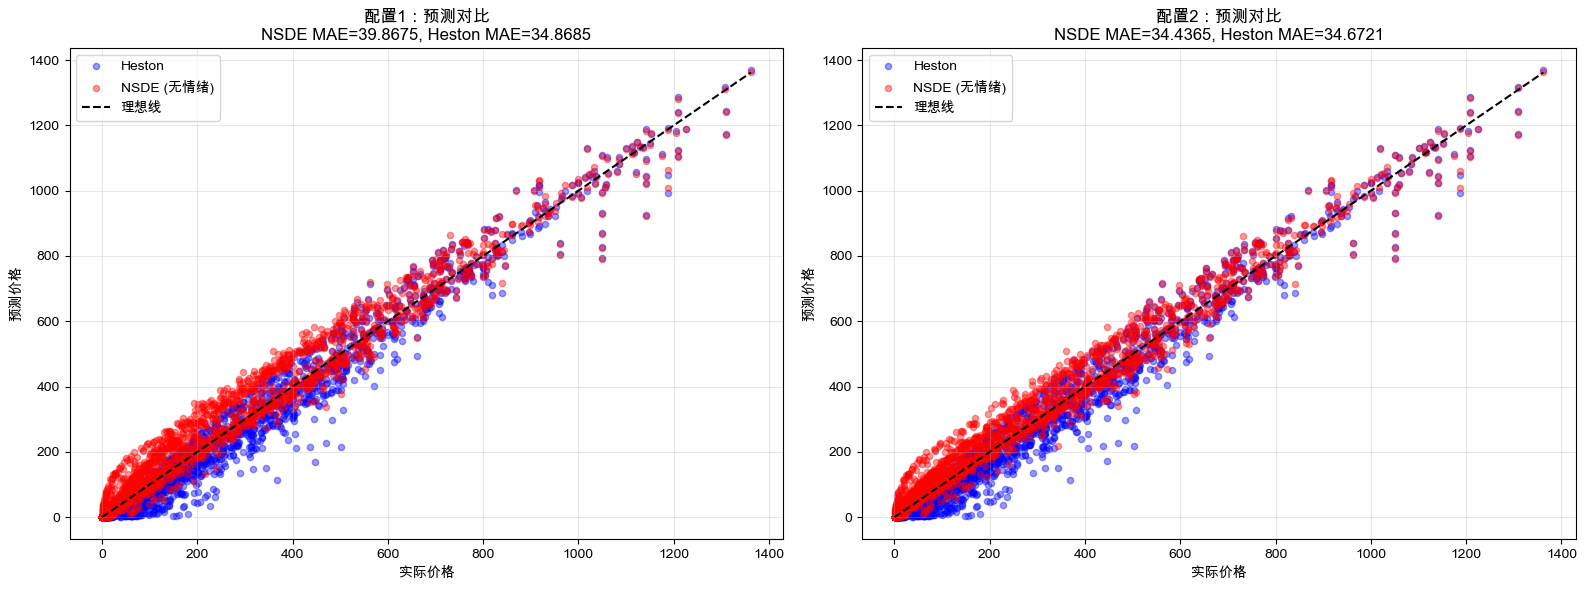


预测对比图已保存到 nsde_no_sentiment_predictions.png


In [9]:
# 预测对比图
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

actual = df_test_sample['close'].values

# 配置1对比
axes[0].scatter(actual, pred_heston1, alpha=0.4, s=20, label='Heston', color='blue')
axes[0].scatter(actual, pred_nsde1, alpha=0.4, s=20, label='NSDE (无情绪)', color='red')
axes[0].plot([0, actual.max()], [0, actual.max()], 'k--', linewidth=1.5, label='理想线')
axes[0].set_xlabel('实际价格')
axes[0].set_ylabel('预测价格')
axes[0].set_title(f'配置1：预测对比\nNSDE MAE={metrics_nsde1["MAE"]:.4f}, Heston MAE={heston_metrics_1["MAE"]:.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 配置2对比
axes[1].scatter(actual, pred_heston2, alpha=0.4, s=20, label='Heston', color='blue')
axes[1].scatter(actual, pred_nsde2, alpha=0.4, s=20, label='NSDE (无情绪)', color='red')
axes[1].plot([0, actual.max()], [0, actual.max()], 'k--', linewidth=1.5, label='理想线')
axes[1].set_xlabel('实际价格')
axes[1].set_ylabel('预测价格')
axes[1].set_title(f'配置2：预测对比\nNSDE MAE={metrics_nsde2["MAE"]:.4f}, Heston MAE={heston_metrics_2["MAE"]:.4f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('nsde_no_sentiment_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n预测对比图已保存到 nsde_no_sentiment_predictions.png")

## 6. 残差分析

检查神经网络学习到的残差幅度

In [10]:
# 分析配置1的残差
print("=" * 60)
print("配置1：残差分析")
print("=" * 60)

# 随机采样一些状态
sample_states = df_test_sample.sample(n=min(100, len(df_test_sample)), random_state=SEED)

residuals_1 = {'sigma_S': [], 'mu_v': [], 'sigma_v': []}

for _, row in sample_states.iterrows():
    features = np.array([[
        1.0,  # S/S0 = 1.0
        row['hv_20d'] ** 2,
        row['risk_free_rate'],
        0.0  # t=0
    ]])
    
    residuals_1['sigma_S'].append(np.tanh(nsde1.net_sigma_S.predict(features)[0]) * nsde1.residual_scale)
    residuals_1['mu_v'].append(np.tanh(nsde1.net_mu_v.predict(features)[0]) * nsde1.residual_scale)
    residuals_1['sigma_v'].append(np.tanh(nsde1.net_sigma_v.predict(features)[0]) * nsde1.residual_scale)

residuals_sigma_v_1 = np.array(residuals_1['sigma_v'])
print(f"\nΔσ_v 统计:")
print(f"  均值: {residuals_sigma_v_1.mean():.4f}")
print(f"  标准差: {residuals_sigma_v_1.std():.4f}")
print(f"  范围: [{residuals_sigma_v_1.min():.4f}, {residuals_sigma_v_1.max():.4f}]")

# 分析配置2的残差
print("\n" + "=" * 60)
print("配置2：残差分析")
print("=" * 60)

residuals_2 = {'sigma_S': [], 'mu_v': [], 'sigma_v': []}

for _, row in sample_states.iterrows():
    features = np.array([[
        1.0,
        row['hv_20d'] ** 2,
        row['risk_free_rate'],
        0.0
    ]])
    
    residuals_2['sigma_S'].append(np.tanh(nsde2.net_sigma_S.predict(features)[0]) * nsde2.residual_scale)
    residuals_2['mu_v'].append(np.tanh(nsde2.net_mu_v.predict(features)[0]) * nsde2.residual_scale)
    residuals_2['sigma_v'].append(np.tanh(nsde2.net_sigma_v.predict(features)[0]) * nsde2.residual_scale)

residuals_sigma_v_2 = np.array(residuals_2['sigma_v'])
print(f"\nΔσ_v 统计:")
print(f"  均值: {residuals_sigma_v_2.mean():.4f}")
print(f"  标准差: {residuals_sigma_v_2.std():.4f}")
print(f"  范围: [{residuals_sigma_v_2.min():.4f}, {residuals_sigma_v_2.max():.4f}]")

配置1：残差分析

Δσ_v 统计:
  均值: 0.0717
  标准差: 0.1084
  范围: [0.0000, 0.2719]

配置2：残差分析

Δσ_v 统计:
  均值: 0.0041
  标准差: 0.0068
  范围: [0.0000, 0.0294]


## 7. 诊断与总结

In [11]:
# ===== 配置1诊断 =====
print("\n" + "=" * 60)
print("【配置1：baseline_mse_hv (rs=0.3, n=500, rho=-0.082)】")

print(f"\n1. 性能对比:")
print(f"   Heston MAE: {heston_metrics_1['MAE']:.4f}")
print(f"   NSDE MAE:   {metrics_nsde1['MAE']:.4f}")
ratio_1 = metrics_nsde1['MAE'] / heston_metrics_1['MAE']
print(f"   比值: {ratio_1:.3f} ({'✓ NSDE更好' if ratio_1 < 1.0 else '❌ Heston更好'})")

print(f"\n2. 训练收敛:")
print(f"   最终训练 MAE: {nsde1.history_['mae'][-1]:.4f}")
print(f"   最终训练 Loss: {nsde1.history_['loss'][-1]:.4f}")

if 'grad_norm_sigma_v' in nsde1.history_:
    avg_grad_sigma_v1 = np.mean(nsde1.history_['grad_norm_sigma_v'])
    print(f"\n3. 梯度健康度:")
    print(f"   σ_v 平均梯度: {avg_grad_sigma_v1:.2e}")
    if avg_grad_sigma_v1 < 1e-5:
        print("   ❌ 梯度消失问题")
    else:
        print("   ✓ 梯度正常")

print(f"\n4. 网络残差幅度:")
print(f"   Δσ_v 范围: [{residuals_sigma_v_1.min():.4f}, {residuals_sigma_v_1.max():.4f}]")
if np.abs(residuals_sigma_v_1).max() < 0.005:
    print("   ❌ 残差过小")
else:
    print("   ✓ 残差合理")

# ===== 配置2诊断 =====
print("\n" + "=" * 60)
print("【配置2：baseline_mse_hv_0.2rs_-0.07rho (rs=0.2, n=2000, rho=-0.07)】")

print(f"\n1. 性能对比:")
print(f"   Heston MAE: {heston_metrics_2['MAE']:.4f}")
print(f"   NSDE MAE:   {metrics_nsde2['MAE']:.4f}")
ratio_2 = metrics_nsde2['MAE'] / heston_metrics_2['MAE']
print(f"   比值: {ratio_2:.3f} ({'✓ NSDE更好' if ratio_2 < 1.0 else '❌ Heston更好'})")

print(f"\n2. 训练收敛:")
print(f"   最终训练 MAE: {nsde2.history_['mae'][-1]:.4f}")
print(f"   最终训练 Loss: {nsde2.history_['loss'][-1]:.4f}")

if 'grad_norm_sigma_v' in nsde2.history_:
    avg_grad_sigma_v2 = np.mean(nsde2.history_['grad_norm_sigma_v'])
    print(f"\n3. 梯度健康度:")
    print(f"   σ_v 平均梯度: {avg_grad_sigma_v2:.2e}")
    if avg_grad_sigma_v2 < 1e-5:
        print("   ❌ 梯度消失问题")
    else:
        print("   ✓ 梯度正常")

print(f"\n4. 网络残差幅度:")
print(f"   Δσ_v 范围: [{residuals_sigma_v_2.min():.4f}, {residuals_sigma_v_2.max():.4f}]")
if np.abs(residuals_sigma_v_2).max() < 0.005:
    print("   ❌ 残差过小")
else:
    print("   ✓ 残差合理")

# ===== 总结 =====
print("\n" + "=" * 60)
print("【总结：无情绪因子NSDE vs 有情绪因子NSDE (stage_5)】")
print("=" * 60)

if ratio_1 < 1.0 and ratio_2 < 1.0:
    print("\n✓ 无情绪因子的NSDE仍然能够超越Heston基准")
    print("  这说明神经网络的非线性拟合能力是主要贡献因素")
    print("\n需要进一步比较:")
    print("  - 无情绪版本 vs 有情绪版本 (stage_5) 的MAE差异")
    print("  - 情绪因子是否带来了额外的定价信息")
else:
    print("\n⚠️ 无情绪因子的NSDE未能超越Heston基准")
    print("  可能原因：")
    print("  - 输入维度减少（4维 vs 6维）导致模型容量下降")
    print("  - 需要更多的训练样本或更深的网络结构")
    print("\n建议：")
    print("  1. 增加网络深度到[64, 64]或[32, 32, 32]")
    print("  2. 增加训练样本到5000")
    print("  3. 增加训练轮数到50")

print("\n" + "=" * 60)


【配置1：baseline_mse_hv (rs=0.3, n=500, rho=-0.082)】

1. 性能对比:
   Heston MAE: 34.8685
   NSDE MAE:   39.8675
   比值: 1.143 (❌ Heston更好)

2. 训练收敛:
   最终训练 MAE: 16.3040
   最终训练 Loss: 635.6451

3. 梯度健康度:
   σ_v 平均梯度: 1.11e+02
   ✓ 梯度正常

4. 网络残差幅度:
   Δσ_v 范围: [0.0000, 0.2719]
   ✓ 残差合理

【配置2：baseline_mse_hv_0.2rs_-0.07rho (rs=0.2, n=2000, rho=-0.07)】

1. 性能对比:
   Heston MAE: 34.6721
   NSDE MAE:   34.4365
   比值: 0.993 (✓ NSDE更好)

2. 训练收敛:
   最终训练 MAE: 17.3155
   最终训练 Loss: 791.6823

3. 梯度健康度:
   σ_v 平均梯度: 1.07e+02
   ✓ 梯度正常

4. 网络残差幅度:
   Δσ_v 范围: [0.0000, 0.0294]
   ✓ 残差合理

【总结：无情绪因子NSDE vs 有情绪因子NSDE (stage_5)】

⚠️ 无情绪因子的NSDE未能超越Heston基准
  可能原因：
  - 输入维度减少（4维 vs 6维）导致模型容量下降
  - 需要更多的训练样本或更深的网络结构

建议：
  1. 增加网络深度到[64, 64]或[32, 32, 32]
  2. 增加训练样本到5000
  3. 增加训练轮数到50

